In [76]:
import torch
from torch import nn # nn contains all of pytorch's building blocks for neural networks
import matplotlib.pyplot as plt

# workflow
## create data

In [77]:
# create parameters
weight= 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim = 1)
Y = weight * X + bias

X.shape, Y.shape

(torch.Size([50, 1]), torch.Size([50, 1]))

In [78]:
# splitting data into training and test data sets
X_train, y_train = X[:40], Y[:40]
X_test, y_test = X[40:], Y[40:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([40, 1]),
 torch.Size([10, 1]),
 torch.Size([40, 1]),
 torch.Size([10, 1]))

In [79]:
# visulize data
def plot_predictions(train_data = X_train,train_labels = y_train, test_data = X_test, test_labels = y_test, predictions = None):
    # plots data
    plt.figure(figsize=(10,7))

    plt.scatter(train_data, train_labels,c = "b", s =4, label = "training data")
    plt.scatter(test_data, test_labels,c = "g", s =4, label = "testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions, c = "r", s =4, label = "Predictions")
    
    plt.legend(prop = {"size":14})
    plt.show()


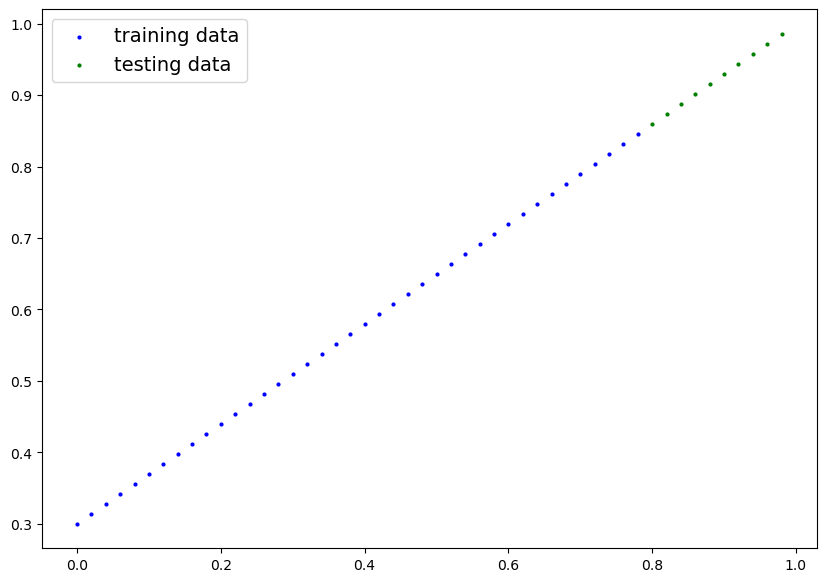

In [80]:
plot_predictions()

## building model

In [81]:
# create linear regression model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
    
    #forward method to define model
    def forward(self,x:torch.tensor) -> torch.tensor:
        return self.weights * x + self.bias

In [82]:
# check parameters of PyTorch Model
torch.manual_seed(42)
model_0 = LinearRegressionModel()
print(list(model_0.parameters()))
print(model_0.state_dict())

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


## Fitting the model to data (training)

In [103]:
# loss function to measure prediction
loss_fn = nn.L1Loss() # class

# optimizer: adjust parameters,training and test loop
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.00001) # lr = learning rate

In [110]:
# build traning loop
torch.manual_seed(42)

#save results
epoch_count = []
loss_values = []
test_loss_values = []

epochs = 100
for epoch in range(epochs):
    # set the model to traning mode - set all parameters that requie gradients to 
    model_0.train()
    # forward pass
    y_pred = model_0(X_train)
    # calculate the loss
    Loss = loss_fn(y_pred, y_train)
    #print("loss: ", Loss)
    # optimizer zero grad
    optimizer.zero_grad()
    # perform backpropogation on the loss 
    Loss.backward()
    # step the optimizer(perform gradient descent)
    optimizer.step()

    # testing
    model_0.eval() # turn off gradient tracking(dropout/batch norm layers)
    with torch.inference_mode(): # turn off gradient tracking
        # forward pass
        test_pred = model_0(X_test)
        # Calculate the test loss
        test_loss = loss_fn(test_pred,y_test)
    
    # print
    print("Epoch:",epoch,"Loss:",Loss,"Test Loss:",test_loss)
    print(model_0.state_dict())
    epoch_count.append(epoch)
    loss_values.append(Loss.detach().item())
    test_loss_values.append(test_loss.item())



Epoch: 0 Loss: tensor(5.4546e-06, grad_fn=<MeanBackward0>) Test Loss: tensor(1.2112e-05)
OrderedDict({'weights': tensor([0.7000]), 'bias': tensor([0.3000])})
Epoch: 1 Loss: tensor(5.0955e-06, grad_fn=<MeanBackward0>) Test Loss: tensor(1.1021e-05)
OrderedDict({'weights': tensor([0.7000]), 'bias': tensor([0.3000])})
Epoch: 2 Loss: tensor(4.7527e-06, grad_fn=<MeanBackward0>) Test Loss: tensor(1.0604e-05)
OrderedDict({'weights': tensor([0.7000]), 'bias': tensor([0.3000])})
Epoch: 3 Loss: tensor(4.4085e-06, grad_fn=<MeanBackward0>) Test Loss: tensor(9.5248e-06)
OrderedDict({'weights': tensor([0.7000]), 'bias': tensor([0.3000])})
Epoch: 4 Loss: tensor(4.0658e-06, grad_fn=<MeanBackward0>) Test Loss: tensor(8.7798e-06)
OrderedDict({'weights': tensor([0.7000]), 'bias': tensor([0.3000])})
Epoch: 5 Loss: tensor(3.7253e-06, grad_fn=<MeanBackward0>) Test Loss: tensor(7.6950e-06)
OrderedDict({'weights': tensor([0.7000]), 'bias': tensor([0.3000])})
Epoch: 6 Loss: tensor(3.3855e-06, grad_fn=<MeanBackw

## Making predictions and evaluating a model (inference)

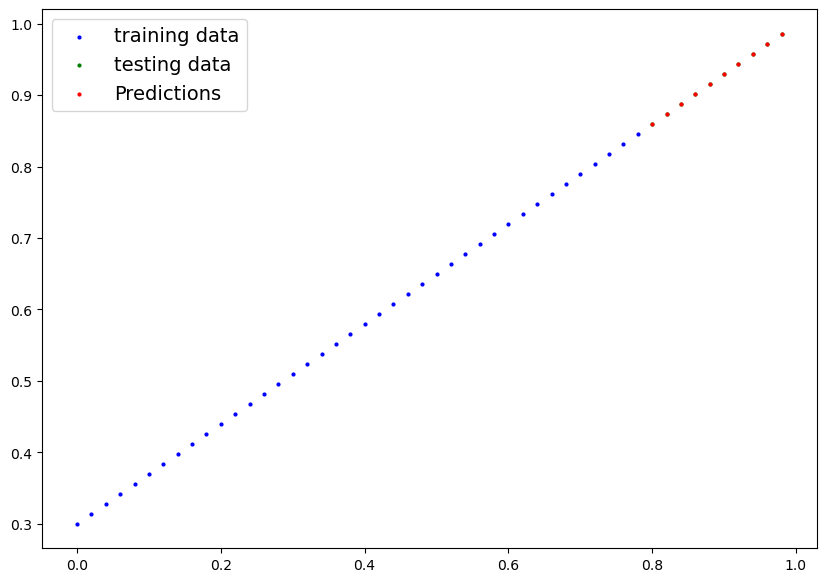

In [118]:
# plot the predictions
with torch.inference_mode():
    y_preds = model_0(X_test)

# similar with no.grad() but inference_mode is recommended here
# with torch.no_grad():
#     y_preds = model_0(X_test)

plot_predictions(predictions=y_preds)

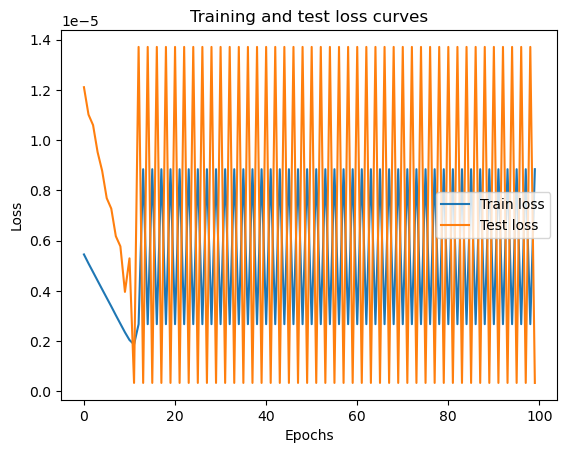

In [112]:
# plot the loss curves
plt.plot(epoch_count, loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

## Saving and loading a model

In [115]:
# save model
from pathlib import Path

# create model directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# create model save path 
MODEL_NAME = "01_pytorch_workflow_model_0.pth" # .pt or .pth
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save the model stat
print("saving model to:", MODEL_SAVE_PATH)
torch.save(model_0.state_dict(),MODEL_SAVE_PATH)


saving model to: models/01_pytorch_workflow_model_0.pth


In [116]:
# load state_sict()

# instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

#load
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.7000])), ('bias', tensor([0.3000]))])

In [ ]:
# make predictions and evaluate the answer
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# Putting it all together

In [1]:
# import Pytorh and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path

# setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

using device: cuda


## data

In [4]:
# visulize data
def plot_predictions(train_data = X_train,train_labels = y_train, test_data = X_test, test_labels = y_test, predictions = None):
    # plots data
    plt.figure(figsize=(10,7))

    plt.scatter(train_data, train_labels,c = "b", s =4, label = "training data")
    plt.scatter(test_data, test_labels,c = "g", s =4, label = "testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions, c = "r", s =4, label = "Predictions")
    
    plt.legend(prop = {"size":14})
    plt.show()

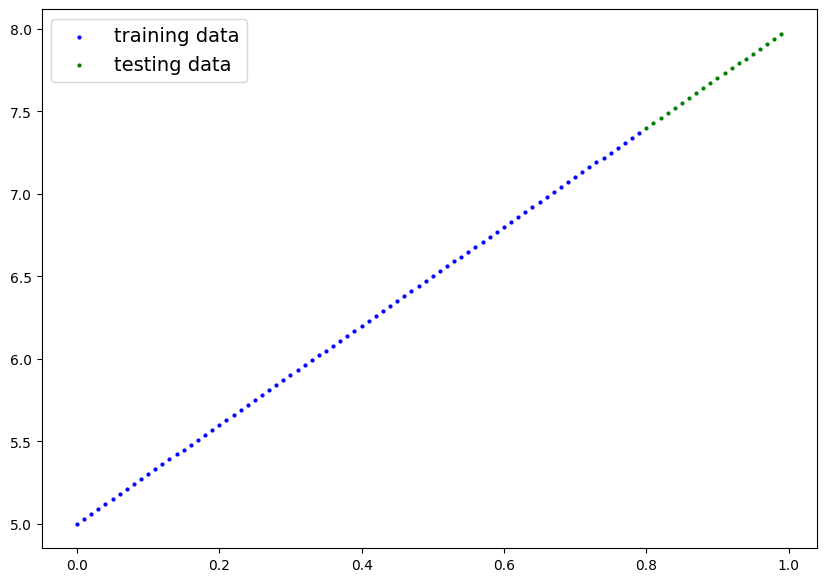

In [5]:
# create data using linear regression
a = 3
b = 5

# create range values
start = 0
end=1 
step = 0.01

# create dataset
X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = a * X + b

# seprate train and test
train_split = int(0.8 * len(X))
X_train = X[:train_split]
X_test = X[train_split:]
y_train = y[:train_split]
y_test = y[train_split:]

# plot
plot_predictions(X_train,y_train,X_test,y_test)



## linear regression model

In [6]:
# create linear regression model class
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
    
    #forward method to define model
    def forward(self,x:torch.tensor) -> torch.tensor:
        return self.linear_layer(x)

In [12]:
# train model
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1.to(device)
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# loss function
loss_fn = nn.L1Loss()
# optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(),lr=0.1)

#training loop
epochs = 500
for epoch in range(epochs):
    model_1.train()
    y_pred = model_1(X_train)
    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred,y_test)
    print("Epoch:",epoch,"Loss:",loss,"Test Loss:",test_loss)


Epoch: 0 Loss: tensor(5.0530, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(6.0354, device='cuda:0')
Epoch: 1 Loss: tensor(4.9374, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.9000, device='cuda:0')
Epoch: 2 Loss: tensor(4.8218, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.7647, device='cuda:0')
Epoch: 3 Loss: tensor(4.7062, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.6293, device='cuda:0')
Epoch: 4 Loss: tensor(4.5906, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.4940, device='cuda:0')
Epoch: 5 Loss: tensor(4.4750, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.3586, device='cuda:0')
Epoch: 6 Loss: tensor(4.3594, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.2233, device='cuda:0')
Epoch: 7 Loss: tensor(4.2438, device='cuda:0', grad_fn=<MeanBackward0>) Test Loss: tensor(5.0879, device='cuda:0')
Epoch: 8 Loss: tensor(4.1282, device='cuda:0', grad_fn=<MeanBackward0>) Test Los

## evaluating predictions

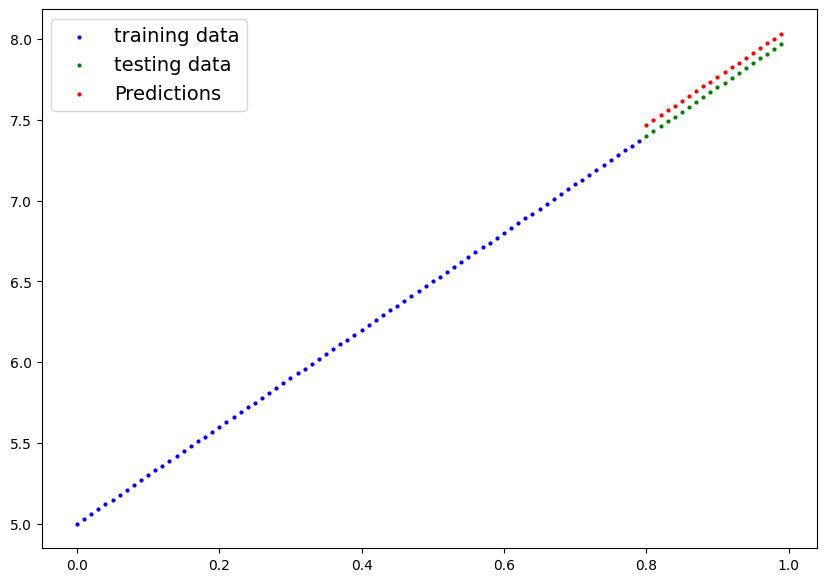

In [13]:
with torch.inference_mode():
    y_preds = model_1(X_test)
plot_predictions(predictions=y_preds.cpu())# numpy works on cpu

## save and load

In [14]:
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

MODEL_NAME = "01_pytorch_workflow_model_1.pth" # .pt or .pth
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save the model stat
print("saving model to:", MODEL_SAVE_PATH)
torch.save(model_1.state_dict(),MODEL_SAVE_PATH)

saving model to: models/01_pytorch_workflow_model_1.pth


In [15]:
loaded_model_1 = LinearRegressionModelV2()

#load
loaded_model_1.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model_1.to(device)
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[2.9643]], device='cuda:0')),
             ('linear_layer.bias', tensor([5.0975], device='cuda:0'))])